# QDF Predict 비교 노트북 — NumPy vs Rust

`run_pipeline.ipynb` 의 자매 노트북. 같은 측정 인프라(`bench/sampler.py`)로 **추론(inference)** 경로에 한정해 NumPy/Rust 백엔드를 비교합니다.

- **측정 대상**: `bench/profile_predict.py` 가 돌리는 `model.forward(data)` (no_grad). 학습과 달리 backward / optimizer 가 없어, Rust LCAO 패치가 학습보다 더 유리해질 수 있습니다.
- **샘플 source**: 데이터셋의 `test_<field>` split (production `predict/predict.py` 와 동일).
- **전처리·shard 생성**: 이 노트북은 *재실행하지 않습니다*. 둘 다 `run_pipeline.ipynb` 에서 이미 만든 산출물을 그대로 사용합니다 (없을 때만 안내).
- **메트릭**: wall time, peak RSS, CPU%(PDH `\Process V2`), XPU%(PDH `\GPU Engine`). 기본 sampling tick = 100 ms.

## 셀 순서
1. 공통 설정 + 환경 확인 + `qdf_io` 빌드(필요 시)
2. 전제 산출물 확인 (test split `.npy/` 와 `_shard.bin`)
3. NumPy vs Rust 4 조합 측정
4. 요약 표
5. 시각화 (막대 / 시계열 / CPU+XPU 결합)

## 0. 공통 설정

In [6]:
import importlib
import os
import re
import sys
from pathlib import Path

# Resolve repo paths (notebook lives in QuantumDeepField_molecule/bench/).
NB_DIR = Path.cwd()
if NB_DIR.name != "bench":
    NB_DIR = Path("QuantumDeepField_molecule/bench").resolve()
QDF_ROOT = NB_DIR.parent
REPO_ROOT = QDF_ROOT.parent
PY = Path(sys.executable)

# --- USER CHOICES ---------------------------------------------------------
DATASET = "QM9under14atoms_atomizationenergy_eV"
BASIS_SET = "6-31G"
RADIUS = "0.75"
GRID_INTERVAL = "0.3"
OPERATION = "sum"   # match how the dataset was trained (sum / mean).
PREDICT_SPLIT = "test"
# --------------------------------------------------------------------------

BENCH_DIR = QDF_ROOT / "bench"
if str(BENCH_DIR) not in sys.path:
    sys.path.insert(0, str(BENCH_DIR))

import sampler  # noqa: E402
importlib.reload(sampler)
from sampler import run_with_metrics  # noqa: E402

print(f"REPO_ROOT   : {REPO_ROOT}")
print(f"QDF_ROOT    : {QDF_ROOT}")
print(f"Python      : {PY}")
print(f"Dataset     : {DATASET}")
print(f"Field       : basis={BASIS_SET}, r={RADIUS}, g={GRID_INTERVAL}")
print(f"Split       : {PREDICT_SPLIT}")
print(f"sampler     : {sampler.__file__}")

REPO_ROOT   : c:\DGCL\3DGCL
QDF_ROOT    : c:\DGCL\3DGCL\QuantumDeepField_molecule
Python      : c:\DGCL\3DGCL\.venv\Scripts\python.exe
Dataset     : QM9under14atoms_atomizationenergy_eV
Field       : basis=6-31G, r=0.75, g=0.3
Split       : test
sampler     : c:\DGCL\3DGCL\QuantumDeepField_molecule\bench\sampler.py


## 1. 환경 확인 (Python / torch / XPU / qdf_io)

In [7]:
import platform
import torch

print(f"OS         : {platform.platform()}")
print(f"Python     : {sys.version.split()[0]}")
print(f"torch      : {torch.__version__}")
print(f"XPU avail  : {hasattr(torch, 'xpu') and torch.xpu.is_available()}")
if hasattr(torch, 'xpu') and torch.xpu.is_available():
    print(f"XPU device : {torch.xpu.get_device_name(0)}")
print(f"CPU cores  : {os.cpu_count()}")

try:
    import qdf_io  # type: ignore
    print("qdf_io     : OK", qdf_io.format_info())
    QDF_IO_AVAILABLE = True
except Exception as e:  # pragma: no cover
    print(f"qdf_io     : NOT BUILT  ({e})")
    print("           -> run the 'Build qdf_io' cell below first.")
    QDF_IO_AVAILABLE = False

OS         : Windows-10-10.0.26200-SP0
Python     : 3.10.20
torch      : 2.9.1+xpu
XPU avail  : True
XPU device : Intel(R) Arc(TM) 140V GPU (16GB)
CPU cores  : 8
qdf_io     : OK {'magic': [81, 68, 70, 83, 72, 82, 68, 0], 'version': 1, 'header_size': 64, 'flag_has_property': 1}


## 2. (선택) `qdf_io` 빌드

위 셀에서 `qdf_io: NOT BUILT` 으로 떴다면 한 번만 실행하세요. 이미 빌드돼 있으면 건너뛰어도 됩니다.

In [8]:
BUILD_QDF_IO = not QDF_IO_AVAILABLE

# Force a rebuild if the binary loads but is missing the new ShardWriter
# symbol added in a recent commit. On Windows the rebuild may not be able
# to overwrite the loaded .pyd; the wheel fallback below copes with that.
FORCE_REBUILD_IF_MISSING_SHARDWRITER = True
if QDF_IO_AVAILABLE and FORCE_REBUILD_IF_MISSING_SHARDWRITER:
    try:
        from qdf_io import ShardWriter  # noqa: F401
    except Exception:
        BUILD_QDF_IO = True


def _run(cmd, cwd):
    import subprocess
    args = [str(a) for a in cmd]
    print("$", " ".join(args))
    return subprocess.check_call(args, cwd=str(cwd))


def _try_install_wheel() -> bool:
    wheels_dir = QDF_ROOT / "qdf_io" / "target" / "wheels"
    if not wheels_dir.exists():
        return False
    candidates = sorted(wheels_dir.glob("qdf_io-*.whl"))
    if not candidates:
        return False
    wheel = candidates[-1]
    print(f"Falling back to wheel install: {wheel}")
    try:
        _run([PY, "-m", "pip", "install", "--force-reinstall", "--no-deps", str(wheel)], cwd=REPO_ROOT)
        return True
    except Exception as e:
        print(f"  wheel install failed: {e}")
        return False


if BUILD_QDF_IO:
    maturin = Path(PY).with_name("maturin.exe" if os.name == "nt" else "maturin")
    if not maturin.exists():
        try:
            _run([PY, "-m", "pip", "install", "maturin>=1.7,<2"], cwd=REPO_ROOT)
        except Exception:
            _run(["uv", "pip", "install", "maturin>=1.7,<2"], cwd=REPO_ROOT)
    try:
        _run([str(maturin), "develop", "--release"], cwd=QDF_ROOT / "qdf_io")
    except Exception as e:
        print(f"maturin develop failed (likely locked .pyd): {e}")
        try:
            _run([str(maturin), "build", "--release"], cwd=QDF_ROOT / "qdf_io")
        except Exception as e2:
            print(f"maturin build also failed: {e2}")
        if not _try_install_wheel():
            print(
                "\nCould not refresh qdf_io in-place. The wheel is built under\n"
                "  QuantumDeepField_molecule/qdf_io/target/wheels/\n"
                "Restart this kernel and re-run the cell to pick it up."
            )
    if "qdf_io" in sys.modules:
        try:
            importlib.reload(sys.modules["qdf_io"])
        except Exception:
            pass
    import qdf_io  # noqa: F401
    print("qdf_io     :", qdf_io.format_info())
    print("has ShardWriter:", hasattr(qdf_io, "ShardWriter"))
else:
    print("Skipping build (qdf_io already importable).")

Skipping build (qdf_io already importable).


## 3. 전제 산출물 확인

`predict` 비교에는 다음 두 가지가 필요합니다.

- `<dataset>/<split>_<field>/` 디렉토리(각 분자당 `.npy`) — `train/preprocess.py` 또는 `predict/preprocess.py` 산출물.
- `<dataset>/<split>_<field>_shard.bin` — `bench/convert_to_shard.py` 산출물.

이 노트북은 둘 다 *재생성하지 않습니다*. 없으면 `run_pipeline.ipynb` 의 셀 8 (전처리) / 셀 12 (shard) 를 먼저 실행하세요.

In [9]:
field = f"{BASIS_SET}_{RADIUS}sphere_{GRID_INTERVAL}grid"
dataset_dir = QDF_ROOT / "dataset" / DATASET
split_dir = dataset_dir / f"{PREDICT_SPLIT}_{field}"
shard_path = split_dir.parent / f"{split_dir.name}_shard.bin"

have_npy = split_dir.is_dir() and any(split_dir.glob("*.npy"))
have_shard = shard_path.is_file()
n_npy = sum(1 for _ in split_dir.glob("*.npy")) if split_dir.is_dir() else 0

print(f"split dir   : {split_dir}")
print(f"  npy files : {n_npy}    (need >0)")
print(f"shard file  : {shard_path}")
print(f"  exists    : {have_shard}    (size = {shard_path.stat().st_size if have_shard else 0:,} bytes)")

if not have_npy:
    print("\n*** Missing npy split. Run cell 8 of run_pipeline.ipynb (preprocess) first. ***")
if not have_shard:
    print("\n*** Missing shard file. Run cell 12 of run_pipeline.ipynb (convert_to_shard) first. ***")

BOTH_READY = have_npy and have_shard
print(f"\nready to benchmark: {BOTH_READY}")

split dir   : c:\DGCL\3DGCL\QuantumDeepField_molecule\dataset\QM9under14atoms_atomizationenergy_eV\test_6-31G_0.75sphere_0.3grid
  npy files : 1480    (need >0)
shard file  : c:\DGCL\3DGCL\QuantumDeepField_molecule\dataset\QM9under14atoms_atomizationenergy_eV\test_6-31G_0.75sphere_0.3grid_shard.bin
  exists    : True    (size = 595,385,272 bytes)

ready to benchmark: True


## 4. 측정 — NumPy vs Rust 4 조합

`bench/profile_predict.py` 가 `model.forward(data)` (no_grad) 를 반복합니다. 옵션 의미:

- `loader`   : `npy` = 기존 `train.MyDataset`, `shard` = Rust mmap.
- `pad_impl` : `python` = 원본 LCAO, `rust-pad-only` = pad 만 Rust, `rust` = pad + list_to_batch 모두 Rust.

기본 조합 4가지를 측정하고 메트릭을 `BENCH_RESULTS` 에 누적합니다.

In [10]:
SAMPLE_INTERVAL_S = 0.1   # 10 Hz; drop to 0.05 for 20 Hz reports.

BENCH_RESULTS: list[dict] = []

def _parse_predict_total(text: str):
    m = re.search(r"total counted\s+([0-9.]+)", text)
    return float(m.group(1)) if m else None

def _parse_predict_fwd_ms(text: str):
    m = re.search(r"^forward\s+[0-9.]+\s+[0-9.]+\s+([0-9.]+)", text, flags=re.M)
    return float(m.group(1)) if m else None

def benchmark(label, group, cmd, parsers=None):
    rc, out, samples, summary = run_with_metrics(
        cmd, cwd=str(REPO_ROOT), interval=SAMPLE_INTERVAL_S, stream=True,
        print_summary=True, label=label,
    )
    extras = {}
    if parsers:
        for k, fn in parsers.items():
            try:
                extras[k] = fn(out)
            except Exception:
                extras[k] = None
    BENCH_RESULTS.append({
        "label": label, "group": group, "rc": rc,
        "wall_s": summary.wall_s,
        "peak_rss_mb": summary.peak_rss_mb,
        "mean_rss_mb": summary.mean_rss_mb,
        "peak_cpu_pct": summary.peak_cpu_pct,
        "mean_cpu_pct": summary.mean_cpu_pct,
        "peak_xpu_pct": summary.peak_xpu_pct,
        "mean_xpu_pct": summary.mean_xpu_pct,
        "n_samples": summary.n_samples,
        "samples": samples, **extras,
    })

# (loader, pad_impl, batch, max_batches, warmup)
PREDICT_COMPARE_RUNS = [
    ("npy",   "python",        8, 60, 2),
    ("shard", "python",        8, 60, 2),
    ("shard", "rust-pad-only", 8, 60, 2),
    ("shard", "rust",          8, 60, 2),
]

if not BOTH_READY:
    print("Skipping benchmark: missing npy split or shard (see section 3).")
else:
    for loader, pad_impl, bs, max_b, warmup in PREDICT_COMPARE_RUNS:
        if loader == "shard" and not have_shard:
            print(f"skipping {loader}+{pad_impl}: shard not built")
            continue
        label = f"predict[{loader}+{pad_impl},bs={bs}]"
        cmd = [
            str(PY), str(QDF_ROOT / "bench" / "profile_predict.py"),
            "--dataset", DATASET,
            "--split", PREDICT_SPLIT,
            "--basis-set", BASIS_SET,
            "--radius", RADIUS,
            "--grid-interval", GRID_INTERVAL,
            "--operation", OPERATION,
            "--batch-size", str(bs),
            "--warmup-batches", str(warmup),
            "--max-batches", str(max_b),
            "--loader", loader,
            "--pad-impl", pad_impl,
            "--predict-mode", "test",
        ]
        benchmark(label, group="predict", cmd=cmd,
                  parsers={"counted_total_s": _parse_predict_total,
                           "fwd_ms_per_batch": _parse_predict_fwd_ms})
    print(f"\nrecorded {len(BENCH_RESULTS)} predict runs.")

[predict[npy+python,bs=8]] $ c:\DGCL\3DGCL\.venv\Scripts\python.exe c:\DGCL\3DGCL\QuantumDeepField_molecule\bench\profile_predict.py --dataset QM9under14atoms_atomizationenergy_eV --split test --basis-set 6-31G --radius 0.75 --grid-interval 0.3 --operation sum --batch-size 8 --warmup-batches 2 --max-batches 60 --loader npy --pad-impl python --predict-mode test
  (cwd=c:\DGCL\3DGCL)
  CPU sampler: PDH \Process V2(*)\% Processor Time
  XPU sampler: PDH \GPU Engine(*)\Utilization Percentage
[2026-05-12 13:49:01.418] [warning] [sycl_collector.h:388] Another subscriber already subscribed to Sycl runtime events, so PTI will not subscribe to them. It will affect correctness of PTI profile: e.g. report zero XPU time for CPU callers of GPU kernels.
Device: xpu
XPU device: Intel(R) Arc(TM) 140V GPU (16GB)
N_orbitals: 60
Loader backend: npy   split=test
Directory: C:\DGCL\3DGCL\QuantumDeepField_molecule\dataset\QM9under14atoms_atomizationenergy_eV\test_6-31G_0.75sphere_0.3grid
Files: ['dsgdb9nsd_

## 5. 결과 요약 표

In [11]:
if not BENCH_RESULTS:
    print("BENCH_RESULTS is empty — run section 4 first.")
else:
    cols = [
        ("label",       32, "<", "label",        "{:<32s}"),
        ("wall(s)",      9, ">", "wall_s",       "{:>9.3f}"),
        ("fwd ms/b",    10, ">", "fwd_ms_per_batch", "{:>10.3f}"),
        ("peakRSS(MB)", 12, ">", "peak_rss_mb",  "{:>12.1f}"),
        ("meanCPU%",    10, ">", "mean_cpu_pct", "{:>10.1f}"),
        ("meanXPU%",    10, ">", "mean_xpu_pct", "{:>10.1f}"),
        ("peakXPU%",    10, ">", "peak_xpu_pct", "{:>10.1f}"),
    ]
    header = "  ".join(f"{name:{align}{w}}" for name, w, align, _, _ in cols)
    print(header)
    print("-" * len(header))
    for r in BENCH_RESULTS:
        cells = []
        for name, w, align, key, fmt in cols:
            v = r.get(key)
            if isinstance(v, (int, float)):
                cells.append(fmt.format(v))
            else:
                cells.append(f"{str(v):{align}{w}}")
        print("  ".join(cells))

    base = BENCH_RESULTS[0]
    print(f"\n--- speedup vs baseline ({base['label']}, wall={base['wall_s']:.3f}s) ---")
    for r in BENCH_RESULTS:
        sp = base["wall_s"] / r["wall_s"] if r["wall_s"] > 0 else float("nan")
        print(f"  {r['label']:<32s}  wall={r['wall_s']:7.3f}s  x{sp:5.2f}")

label                               wall(s)    fwd ms/b   peakRSS(MB)    meanCPU%    meanXPU%    peakXPU%
---------------------------------------------------------------------------------------------------------
predict[npy+python,bs=8]              9.804      21.321        2350.7        45.5        16.9       138.1
predict[shard+python,bs=8]            4.654      17.750        2516.4        83.9        30.0       143.0
predict[shard+rust-pad-only,bs=8]      5.086      31.436        2504.0        89.7        34.0       110.6
predict[shard+rust,bs=8]              4.627      24.798        2510.0        87.6        26.6        93.7

--- speedup vs baseline (predict[npy+python,bs=8], wall=9.804s) ---
  predict[npy+python,bs=8]          wall=  9.804s  x 1.00
  predict[shard+python,bs=8]        wall=  4.654s  x 2.11
  predict[shard+rust-pad-only,bs=8]  wall=  5.086s  x 1.93
  predict[shard+rust,bs=8]          wall=  4.627s  x 2.12


## 6. 시각화 — 막대 / 시계열 / CPU+XPU 결합

`SAVE_FIGS=True` 면 `bench/figs/predict_*.png` 로 저장합니다 (보고서용 dpi=160). 시계열은 0.5 s 윈도우 centered moving average 로 스무딩.

  saved c:\DGCL\3DGCL\QuantumDeepField_molecule\bench\figs\predict_bars.png


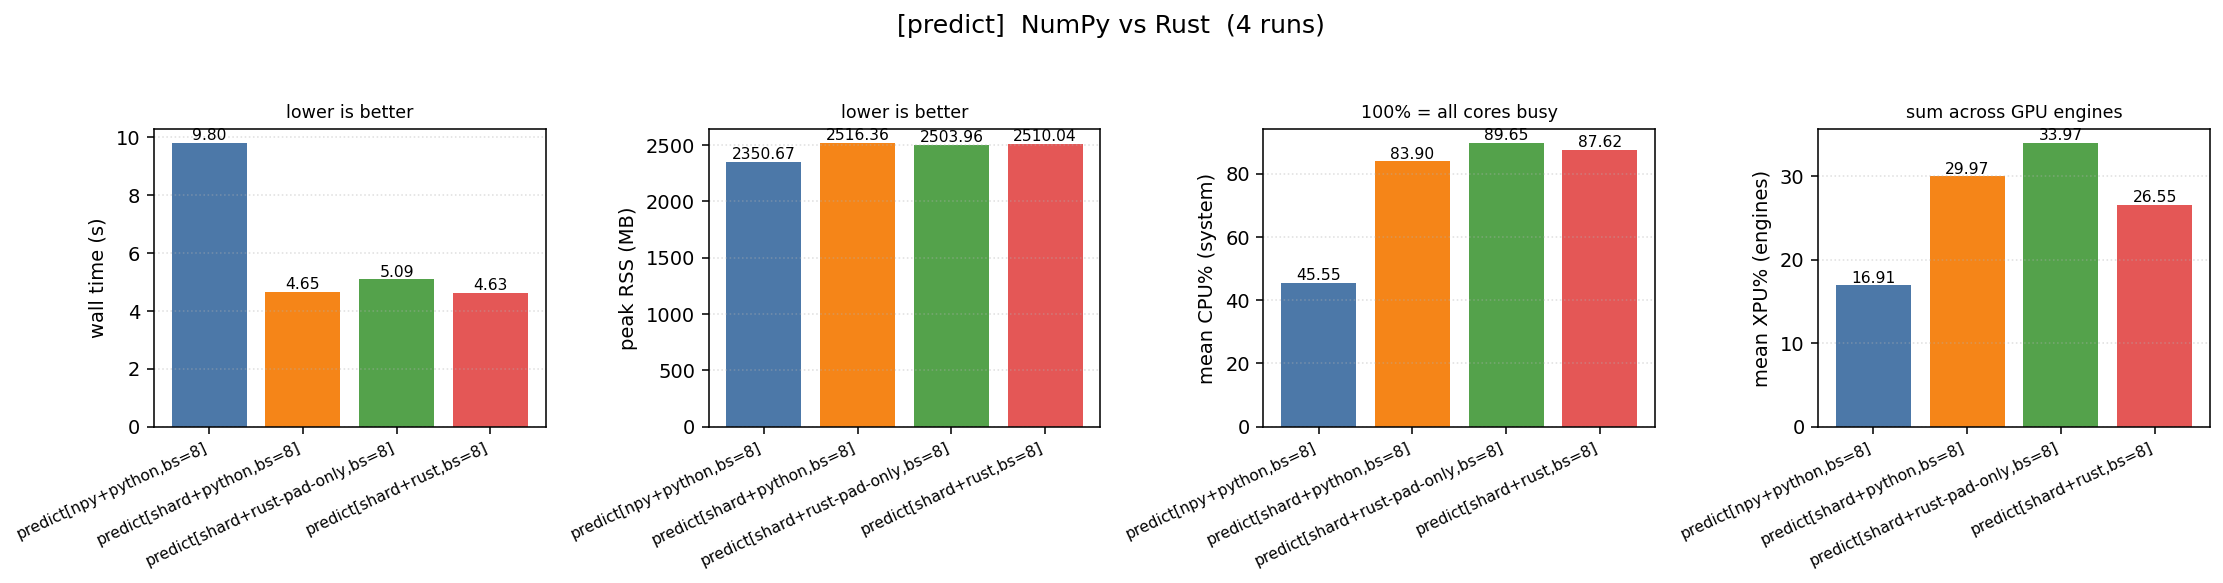

  saved c:\DGCL\3DGCL\QuantumDeepField_molecule\bench\figs\predict_timeseries.png


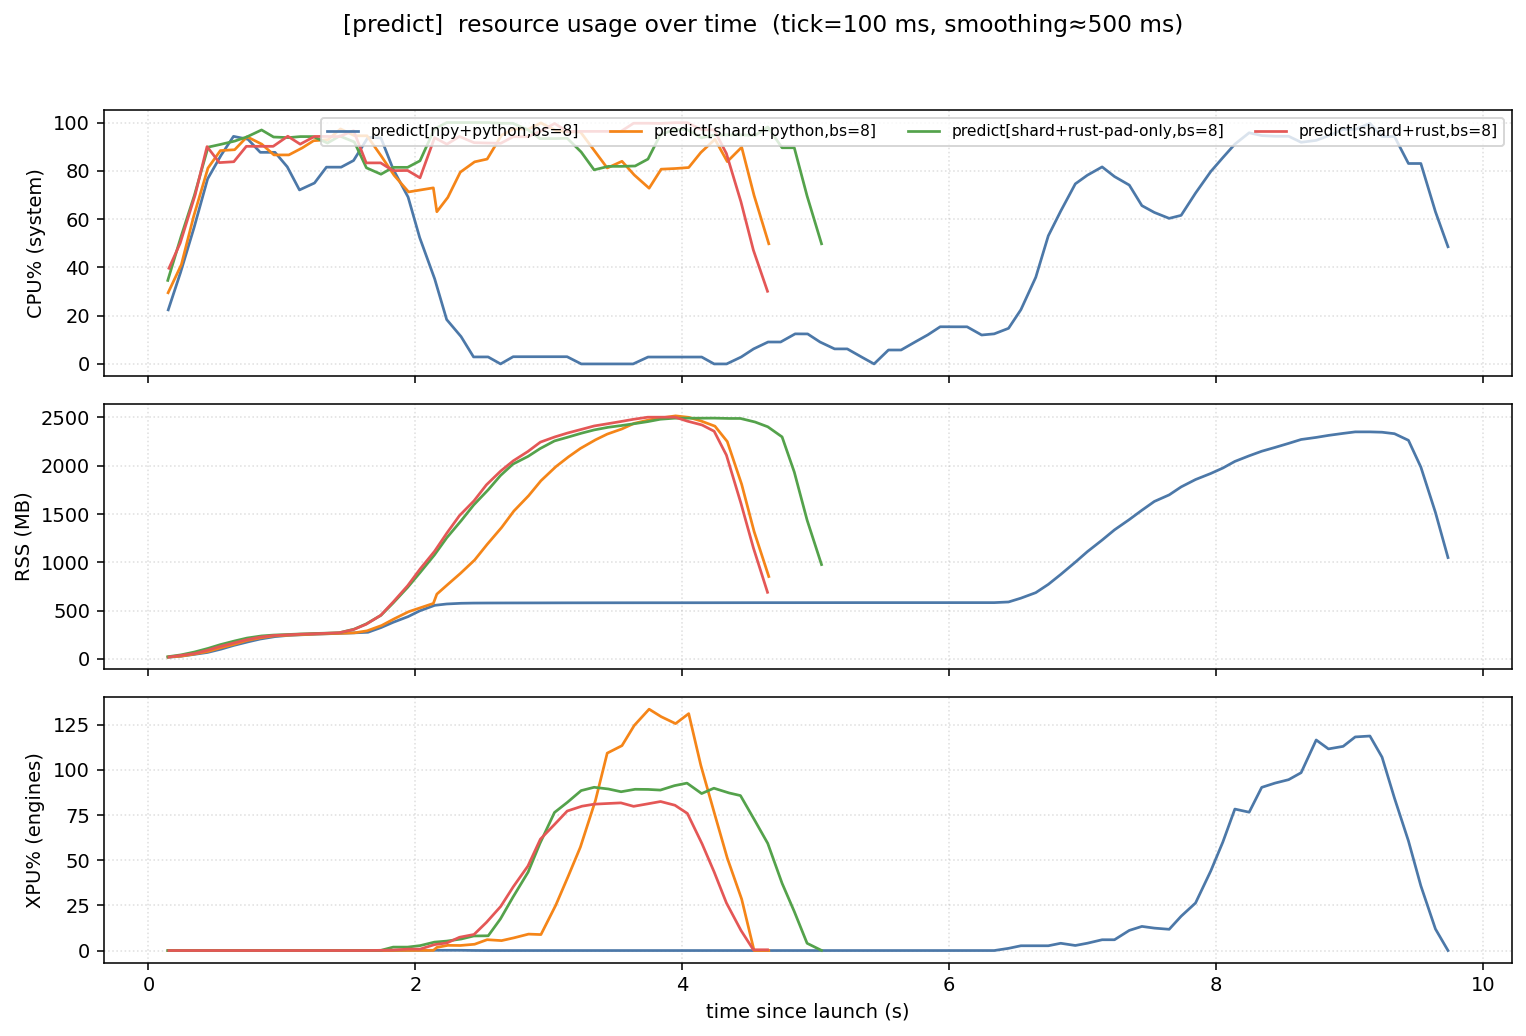

  saved c:\DGCL\3DGCL\QuantumDeepField_molecule\bench\figs\predict_cpu_xpu.png


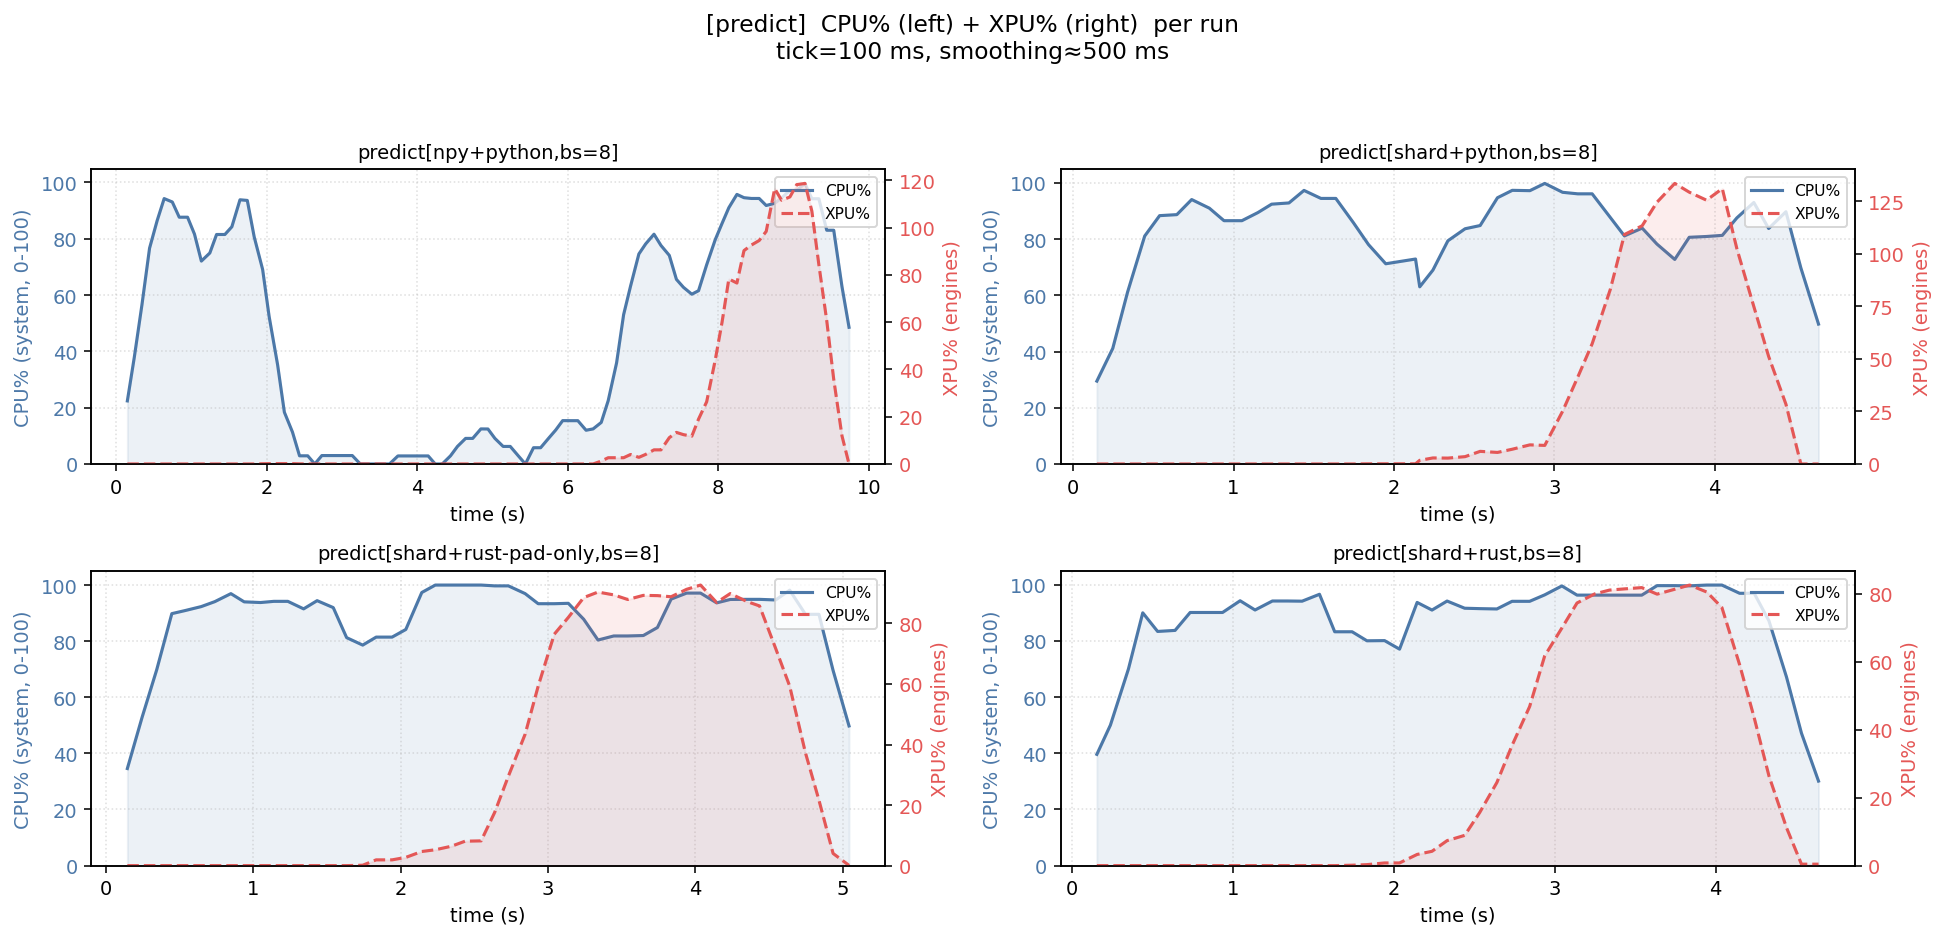

In [12]:
import matplotlib.pyplot as plt
import numpy as np

import time as _time
SAVE_FIGS = True
FIG_DIR = QDF_ROOT / "bench" / "figs"
FIG_TS = _time.strftime("%m%d_%H%M")
if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
SMOOTH_WINDOW_S = 0.5

def _smooth(arr, dt):
    a = np.asarray(arr, dtype=float)
    if a.size == 0 or dt <= 0:
        return a
    w = max(1, int(round(SMOOTH_WINDOW_S / dt)))
    if w <= 1 or a.size < w:
        return a
    return np.convolve(a, np.ones(w) / w, mode="same")

def _dt(samples):
    if len(samples.t) < 2:
        return SAMPLE_INTERVAL_S
    return max(1e-6, float(np.median(np.diff(samples.t))))

def _save(fig, name):
    if SAVE_FIGS:
        out = FIG_DIR / f"{name}_{FIG_TS}.png"
        fig.savefig(out, dpi=160, bbox_inches="tight")
        print(f"  saved {out}")

if not BENCH_RESULTS:
    print("BENCH_RESULTS is empty — run section 4 first.")
else:
    rows = BENCH_RESULTS  # single group: 'predict'
    labels = [r["label"] for r in rows]
    n = len(rows)
    colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2", "#B279A2"][:n]

    # ---- (a) bar chart of scalar summaries ----
    metric_cols = [
        ("wall_s",       "wall time (s)",       "lower is better"),
        ("peak_rss_mb",  "peak RSS (MB)",       "lower is better"),
        ("mean_cpu_pct", "mean CPU% (system)",  "100% = all cores busy"),
        ("mean_xpu_pct", "mean XPU% (engines)", "sum across GPU engines"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), dpi=140)
    fig.suptitle(f"[predict]  NumPy vs Rust  ({n} runs)", fontsize=13)
    for ax, (key, ylabel, sub) in zip(axes, metric_cols):
        vals = [r.get(key) or 0.0 for r in rows]
        bars = ax.bar(range(n), vals, color=colors)
        ax.set_xticks(range(n))
        ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
        ax.set_ylabel(ylabel)
        ax.set_title(sub, fontsize=9)
        ax.grid(axis="y", linestyle=":", alpha=0.4)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=8)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    _save(fig, "predict_bars")
    plt.show()

    # ---- (b) overlay time series ----
    fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True, dpi=140)
    fig.suptitle(f"[predict]  resource usage over time  "
                 f"(tick={SAMPLE_INTERVAL_S*1000:.0f} ms, smoothing≈{SMOOTH_WINDOW_S*1000:.0f} ms)",
                 fontsize=12)
    for r, c in zip(rows, colors):
        s = r["samples"]
        if not s.t:
            continue
        dt = _dt(s)
        axes[0].plot(s.t, _smooth(s.cpu_pct, dt), label=r["label"], color=c, linewidth=1.4)
        axes[1].plot(s.t, _smooth(s.rss_mb,  dt), label=r["label"], color=c, linewidth=1.4)
        axes[2].plot(s.t, _smooth(s.xpu_pct, dt), label=r["label"], color=c, linewidth=1.4)
    axes[0].set_ylabel("CPU% (system)")
    axes[1].set_ylabel("RSS (MB)")
    axes[2].set_ylabel("XPU% (engines)")
    axes[2].set_xlabel("time since launch (s)")
    for ax in axes:
        ax.grid(linestyle=":", alpha=0.4)
    axes[0].legend(fontsize=8, ncol=min(4, n), loc="upper right")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    _save(fig, "predict_timeseries")
    plt.show()

    # ---- (c) combined CPU + XPU per run, twin axes ----
    cols_n = min(2, n)
    grid_rows = (n + cols_n - 1) // cols_n
    fig, axes = plt.subplots(
        grid_rows, cols_n,
        figsize=(7.0 * cols_n, 3.4 * grid_rows),
        dpi=140, squeeze=False,
    )
    fig.suptitle(
        f"[predict]  CPU% (left) + XPU% (right)  per run\n"
        f"tick={SAMPLE_INTERVAL_S*1000:.0f} ms, smoothing≈{SMOOTH_WINDOW_S*1000:.0f} ms",
        fontsize=12,
    )
    axes_flat = [ax for row_ in axes for ax in row_]
    for ax, r in zip(axes_flat, rows):
        s = r["samples"]
        ax.set_title(r["label"], fontsize=10)
        ax.set_xlabel("time (s)")
        ax.grid(linestyle=":", alpha=0.4)
        if not s.t:
            ax.text(0.5, 0.5, "no samples", ha="center", va="center", transform=ax.transAxes)
            continue
        dt = _dt(s)
        cpu = _smooth(s.cpu_pct, dt)
        xpu = _smooth(s.xpu_pct, dt)
        l1, = ax.plot(s.t, cpu, color="#4C78A8", linewidth=1.6, label="CPU%")
        ax.set_ylabel("CPU% (system, 0-100)", color="#4C78A8")
        ax.tick_params(axis="y", labelcolor="#4C78A8")
        ax.fill_between(s.t, 0, cpu, color="#4C78A8", alpha=0.10)
        ax2 = ax.twinx()
        l2, = ax2.plot(s.t, xpu, color="#E45756", linewidth=1.6, linestyle="--", label="XPU%")
        ax2.set_ylabel("XPU% (engines)", color="#E45756")
        ax2.tick_params(axis="y", labelcolor="#E45756")
        ax2.fill_between(s.t, 0, xpu, color="#E45756", alpha=0.10)
        ax.set_ylim(bottom=0)
        ax2.set_ylim(bottom=0)
        ax.legend(handles=[l1, l2], loc="upper right", fontsize=8)
    for ax in axes_flat[len(rows):]:
        ax.set_visible(False)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    _save(fig, "predict_cpu_xpu")
    plt.show()